# **Multiclass Logistic Regression**

This notebook extends the concepts of **Binary Logistic Regression** (classification with **two classes**) to **Multiclass Logistic Regression**, where the model predicts one class from **three or more possible classes**.

The fundamental idea remains the same. The model first computes a **weighted sum of the input features**, then converts it into class probabilities using an appropriate activation function. Instead of making a simple **yes/no** decision, the model identifies the **most probable class** for each input sample.

To solve multiclass classification problems, Logistic Regression commonly uses one of two approaches:

* **One-vs-Rest (OvR):** Trains one binary classifier for each class, treating that class as the positive class and all remaining classes as the negative class.
* **Multinomial Logistic Regression (Softmax Regression):** Trains a single model that directly predicts the probability of each class using the Softmax function.

Both approaches are explained and implemented later in this notebook.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **Generate a Synthetic Multiclass Dataset**

In this step, we generate a synthetic classification dataset using Scikit-learn's `make_classification()` function.

This dataset will be used to train and evaluate a **Multiclass Logistic Regression** model.

The generated dataset contains:

- **1000 samples (rows)**
- **10 input features**
- **3 target classes**
- **3 informative features** that help distinguish between the classes

Since the dataset is generated synthetically, it contains no missing values and is useful for learning and experimenting with classification algorithms.

## **Create a DataFrame**

The generated dataset is converted into a Pandas DataFrame.

This makes it easier to:

- View the dataset
- Perform Exploratory Data Analysis (EDA)
- Calculate statistics
- Visualize the data

In [2]:
# Import the function used to generate a synthetic classification dataset
from sklearn.datasets import make_classification

# Generate a synthetic multiclass classification dataset
X, y = make_classification(
    n_samples=1000,      # Total number of samples (rows) in the dataset
    n_features=10,       # Total number of input features
    n_classes=3,         # Number of target classes
    n_informative=3,     # Number of informative features that help predict the target
    random_state=42      # Ensures reproducible results by fixing the random seed
)

In [3]:
# Display the shape of the generated dataset.
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape: (1000, 10)
Target Vector Shape : (1000,)


## **Creating a Pandas DataFrame**

The generated feature matrix (`X`) is stored as a NumPy array. Although NumPy arrays are efficient for numerical computations, Pandas DataFrames are easier to explore and visualize because they support column names and provide convenient methods such as `head()`, `info()`, and `describe()`.

In [4]:
feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y

df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Target
0,0.771533,-1.474336,2.196646,-0.678992,0.767479,-1.226179,-0.237566,0.681743,1.089962,0.962503,1
1,1.858383,-3.680880,0.227496,-3.818368,0.635968,1.609521,-0.153135,-0.474178,1.341139,-0.771772,2
2,-0.987248,1.539168,0.585904,1.185281,-0.736770,-1.406815,0.684783,-0.322028,-1.451034,1.325432,1
3,-1.022420,1.381787,2.015275,0.861434,1.290644,-1.889649,1.009138,0.363116,-1.844238,0.311110,1
4,-0.131161,-2.079008,1.483744,1.636858,-0.734811,-0.640154,2.666422,-1.085748,-0.892851,0.029796,2


In [5]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9
0,0.771533,-1.474336,2.196646,-0.678992,0.767479,-1.226179,-0.237566,0.681743,1.089962,0.962503
1,1.858383,-3.680880,0.227496,-3.818368,0.635968,1.609521,-0.153135,-0.474178,1.341139,-0.771772
2,-0.987248,1.539168,0.585904,1.185281,-0.736770,-1.406815,0.684783,-0.322028,-1.451034,1.325432
3,-1.022420,1.381787,2.015275,0.861434,1.290644,-1.889649,1.009138,0.363116,-1.844238,0.311110
4,-0.131161,-2.079008,1.483744,1.636858,-0.734811,-0.640154,2.666422,-1.085748,-0.892851,0.029796


In [6]:
# Display five random samples from the dataset.
df.sample(5, random_state=42)

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Target
521,0.017594,-2.145186,-0.283152,0.318794,-2.025040,2.121631,2.500537,0.686858,-1.190006,-2.065303,1
737,-1.216758,1.562506,0.553389,0.974224,-0.033925,-0.845154,1.305874,-1.194523,-2.277010,0.285803,1
740,0.101845,0.031614,1.392039,1.238172,0.111129,0.619033,-0.463974,-1.412726,1.022643,-0.516847,0
660,-0.345263,-0.972580,0.333231,0.182416,1.299150,-0.247336,2.089264,0.332719,-1.635444,-1.333148,2
411,-0.297020,0.524283,-0.488274,0.356777,0.633327,-0.629885,0.132187,0.592567,-0.395918,-2.704392,1


In [7]:
# Display all column names.
df.columns

Index(['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4',
       'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9',
       'Target'],
      dtype='object')

In [8]:
# Count the number of samples in each target class.
df["Target"].value_counts()

,count
Target,
2,335
0,334
1,331


## **Check Dataset Information**

In [9]:
print("Shape:", df.shape)

Shape: (1000, 11)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_0  1000 non-null   float64
 1   Feature_1  1000 non-null   float64
 2   Feature_2  1000 non-null   float64
 3   Feature_3  1000 non-null   float64
 4   Feature_4  1000 non-null   float64
 5   Feature_5  1000 non-null   float64
 6   Feature_6  1000 non-null   float64
 7   Feature_7  1000 non-null   float64
 8   Feature_8  1000 non-null   float64
 9   Feature_9  1000 non-null   float64
 10  Target     1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


`describe()` provides summary statistics for all numerical columns, including:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles (25%, 50%, 75%)
- Maximum

These statistics help us understand the distribution and scale of each feature.

In [11]:
df.describe()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.130336,0.051375,-0.052559,0.055339,-0.024452,-0.021036,0.285654,-0.001282,-0.347635,-0.015398,1.001000
std,0.595379,1.351749,1.013208,1.240593,0.980680,1.040345,1.495208,1.030668,1.381117,1.031167,0.818333
min,-2.064734,-3.680880,-3.007632,-3.818368,-3.176704,-3.601085,-4.496088,-3.221016,-4.659960,-3.688365,0.000000
25%,-0.502042,-1.016139,-0.747616,-0.915044,-0.660671,-0.756535,-0.537917,-0.669992,-1.286116,-0.733474,0.000000
50%,-0.172514,0.055528,-0.017253,0.217239,-0.040797,-0.038112,0.281220,0.004252,-0.611881,-0.038749,1.000000
75%,0.207504,1.058421,0.630374,1.029018,0.685077,0.653784,1.356778,0.697684,0.623235,0.690582,2.000000
max,1.858383,3.969755,3.117681,3.193903,2.935658,3.152057,4.655887,3.076860,3.921778,3.529055,2.000000


/tmp/ipykernel_1394/3824088413.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


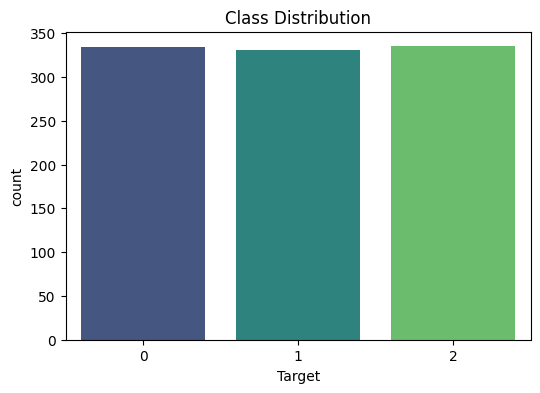

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Target",
    palette="viridis"
)

plt.title("Class Distribution")
plt.show()

Since this dataset is generated using Scikit-learn, there are no missing values.


In [13]:
# Import the train_test_split function to divide the dataset
# into training and testing sets.
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# - 70% of the data is used to train the model.
# - 30% of the data is used to evaluate the model.
# - random_state=42 ensures the split is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

## **Feature Scaling**

Feature Scaling standardizes the input features so that they have a mean of **0** and a standard deviation of **1**.

Since Logistic Regression is an optimization-based algorithm, scaling the features helps:

- Speed up model convergence
- Improve numerical stability
- Ensure that features with larger values do not dominate the learning process

We use **StandardScaler** to scale the training data and apply the same transformation to the test data.

In [14]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Learn scaling parameters from the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling parameters to the test data
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

## **Train the Logistic Regression Model**

The Logistic Regression model learns the relationship between the input features and the target classes.

Parameters:

- **multi_class="ovr"**
  Uses the One-vs-Rest strategy for multiclass classification.

- **solver="liblinear"**
  Optimization algorithm used to train the model.

- **random_state=42**
  Ensures reproducible results.

### **One-vs-Rest (OVR) vs Multinomial (Softmax) — What's the Difference?**

When there are more than 2 classes, Logistic Regression needs a strategy to handle them:

- **One-vs-Rest (`ovr`)** — trains **one binary classifier per class**. For 3 classes, that's 3 separate models:
  - Model 1: "Class 0" vs "Not Class 0"
  - Model 2: "Class 1" vs "Not Class 1"
  - Model 3: "Class 2" vs "Not Class 2"

  Each sample gets a probability from all 3 models, and whichever model is most confident wins.

- **Multinomial (Softmax)** — trains a **single model** that directly outputs a probability for each class at once, with all probabilities summing to 1. This is generally the more "correct" statistical approach for multiclass problems.

**Why does this notebook use `ovr`?** Because it's paired with the `liblinear` solver, which only supports the One-vs-Rest strategy (it doesn't support `multinomial`). Solvers like `lbfgs` or `saga` support both — `multinomial` is usually the recommended default when available, so it's worth experimenting with `solver="lbfgs"` (and dropping `multi_class`, since modern scikit-learn auto-selects multinomial when possible) as a next step.


In [16]:
from sklearn.linear_model import LogisticRegression
# Create a Logistic Regression model using the
# One-vs-Rest (OvR) strategy for multiclass classification.
logistic = LogisticRegression(
    multi_class="ovr",      # Train one binary classifier for each class.
    solver="liblinear",     # Optimization algorithm used to train the model.
    random_state=42         # Ensures reproducible results.
)

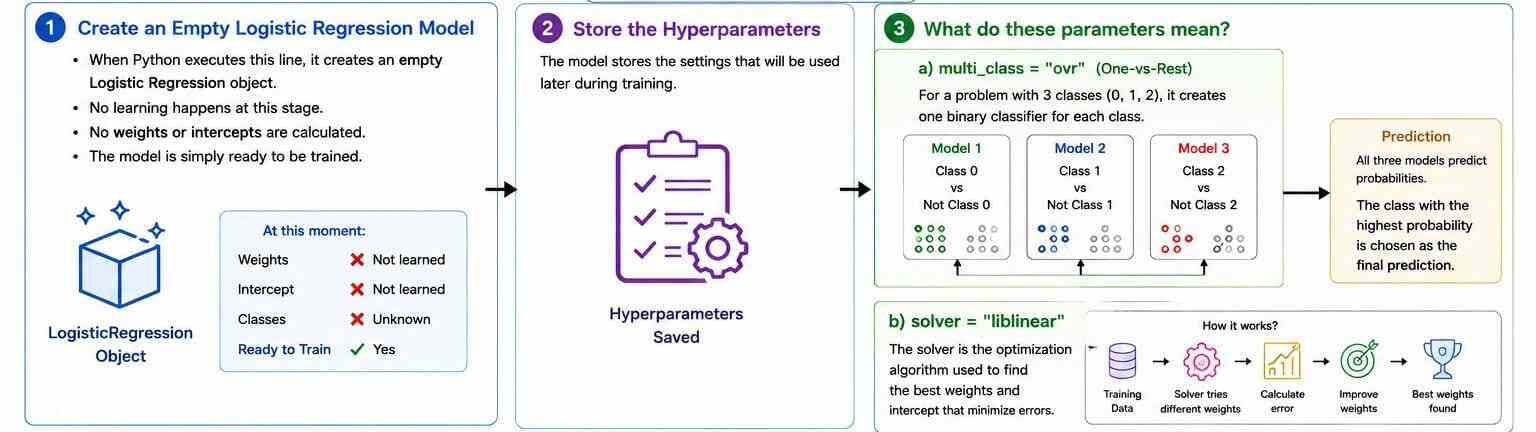

In [17]:
# Train the Logistic Regression model using the
# scaled training dataset.
logistic.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr', random_state=42, solver='liblinear')

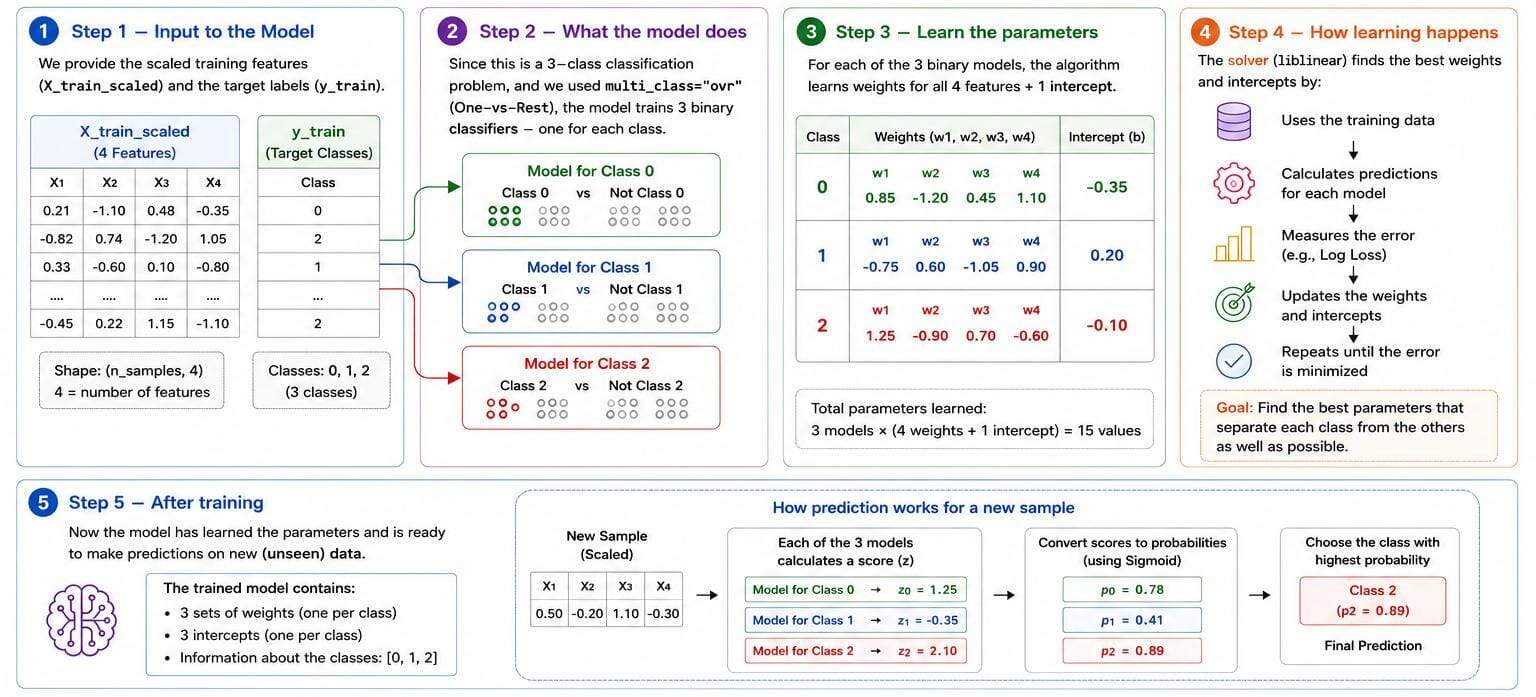

In [18]:
print("Intercept:")
print(logistic.intercept_)

print("\nCoefficients:")
print(logistic.coef_)


Intercept:
[-1.1005407  -0.71208206 -1.32132219]

Coefficients:
[[-0.33710899  1.08312128  0.08183632 -0.13846401 -0.0763057  -0.06973053
  -0.8014485   0.06100076  0.16493002  0.03934705]
 [ 0.13542705 -0.00490501  0.00588655  0.06794259 -0.09422676  0.05048005
  -0.15255989 -0.14540871  0.22068799 -0.01190898]
 [ 0.05548014 -1.20896694 -0.11964036 -0.07939182  0.22668097  0.0137808
   1.27617967  0.11297848 -0.75114065 -0.0482357 ]]


## **Model Predictions**

The trained model predicts the class label for each sample in the test dataset.


In [19]:
# Predict the target class for the test dataset
y_pred = logistic.predict(X_test_scaled)

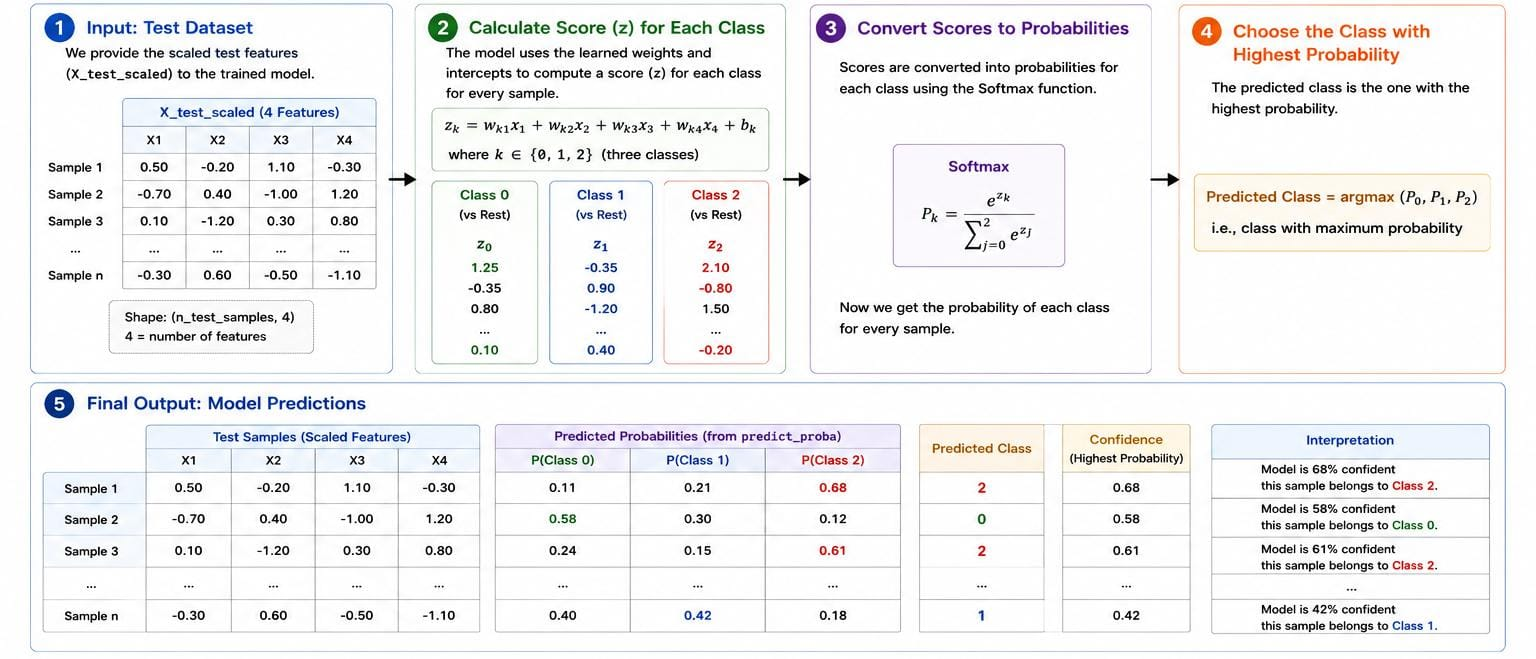

## **Store the Probabilities**

In [20]:
# Predict the probability of each class for every test sample
y_pred_proba = logistic.predict_proba(X_test_scaled)

# Display the probabilities for the first 10 test samples
y_pred_proba[:10]

array([[0.00975914, 0.24507782, 0.74516304],
       [0.48804064, 0.24500401, 0.26695535],
       [0.35524166, 0.58659256, 0.05816577],
       [0.03763296, 0.18340298, 0.77896405],
       [0.40088138, 0.36630836, 0.23281026],
       [0.38304486, 0.51809208, 0.09886305],
       [0.2823077 , 0.21860153, 0.49909076],
       [0.68565396, 0.31122456, 0.00312148],
       [0.57188127, 0.42466337, 0.00345536],
       [0.0281166 , 0.1506751 , 0.8212083 ]])

In [21]:
# Convert the predicted probabilities into a DataFrame
probability_df = pd.DataFrame(
    y_pred_proba,
    columns=[
        "Probability of Class 0",
        "Probability of Class 1",
        "Probability of Class 2"
    ]
)

# Display the first 10 rows
probability_df.head(10)

,Probability of Class 0,Probability of Class 1,Probability of Class 2
0,0.009759,0.245078,0.745163
1,0.488041,0.245004,0.266955
2,0.355242,0.586593,0.058166
3,0.037633,0.183403,0.778964
4,0.400881,0.366308,0.232810
5,0.383045,0.518092,0.098863
6,0.282308,0.218602,0.499091
7,0.685654,0.311225,0.003121
8,0.571881,0.424663,0.003455
9,0.028117,0.150675,0.821208


In [22]:
# Compare the predicted class with its corresponding probabilities

prediction_df = pd.DataFrame({
    "Predicted Class": y_pred,
    "Probability of Class 0": y_pred_proba[:,0],
    "Probability of Class 1": y_pred_proba[:,1],
    "Probability of Class 2": y_pred_proba[:,2]
})

prediction_df.head(10)

,Predicted Class,Probability of Class 0,Probability of Class 1,Probability of Class 2
0,2,0.009759,0.245078,0.745163
1,0,0.488041,0.245004,0.266955
2,1,0.355242,0.586593,0.058166
3,2,0.037633,0.183403,0.778964
4,0,0.400881,0.366308,0.232810
5,1,0.383045,0.518092,0.098863
6,2,0.282308,0.218602,0.499091
7,0,0.685654,0.311225,0.003121
8,0,0.571881,0.424663,0.003455
9,2,0.028117,0.150675,0.821208


In [23]:
# Compare the actual class, predicted class, and predicted probabilities

results_df = pd.DataFrame({
    "Actual Class": y_test,
    "Predicted Class": y_pred,
    "Probability of Class 0": y_pred_proba[:,0],
    "Probability of Class 1": y_pred_proba[:,1],
    "Probability of Class 2": y_pred_proba[:,2]
})

results_df.head(10)

,Actual Class,Predicted Class,Probability of Class 0,Probability of Class 1,Probability of Class 2
0,1,2,0.009759,0.245078,0.745163
1,1,0,0.488041,0.245004,0.266955
2,0,1,0.355242,0.586593,0.058166
3,2,2,0.037633,0.183403,0.778964
4,1,0,0.400881,0.366308,0.232810
5,2,1,0.383045,0.518092,0.098863
6,1,2,0.282308,0.218602,0.499091
7,0,0,0.685654,0.311225,0.003121
8,0,0,0.571881,0.424663,0.003455
9,2,2,0.028117,0.150675,0.821208


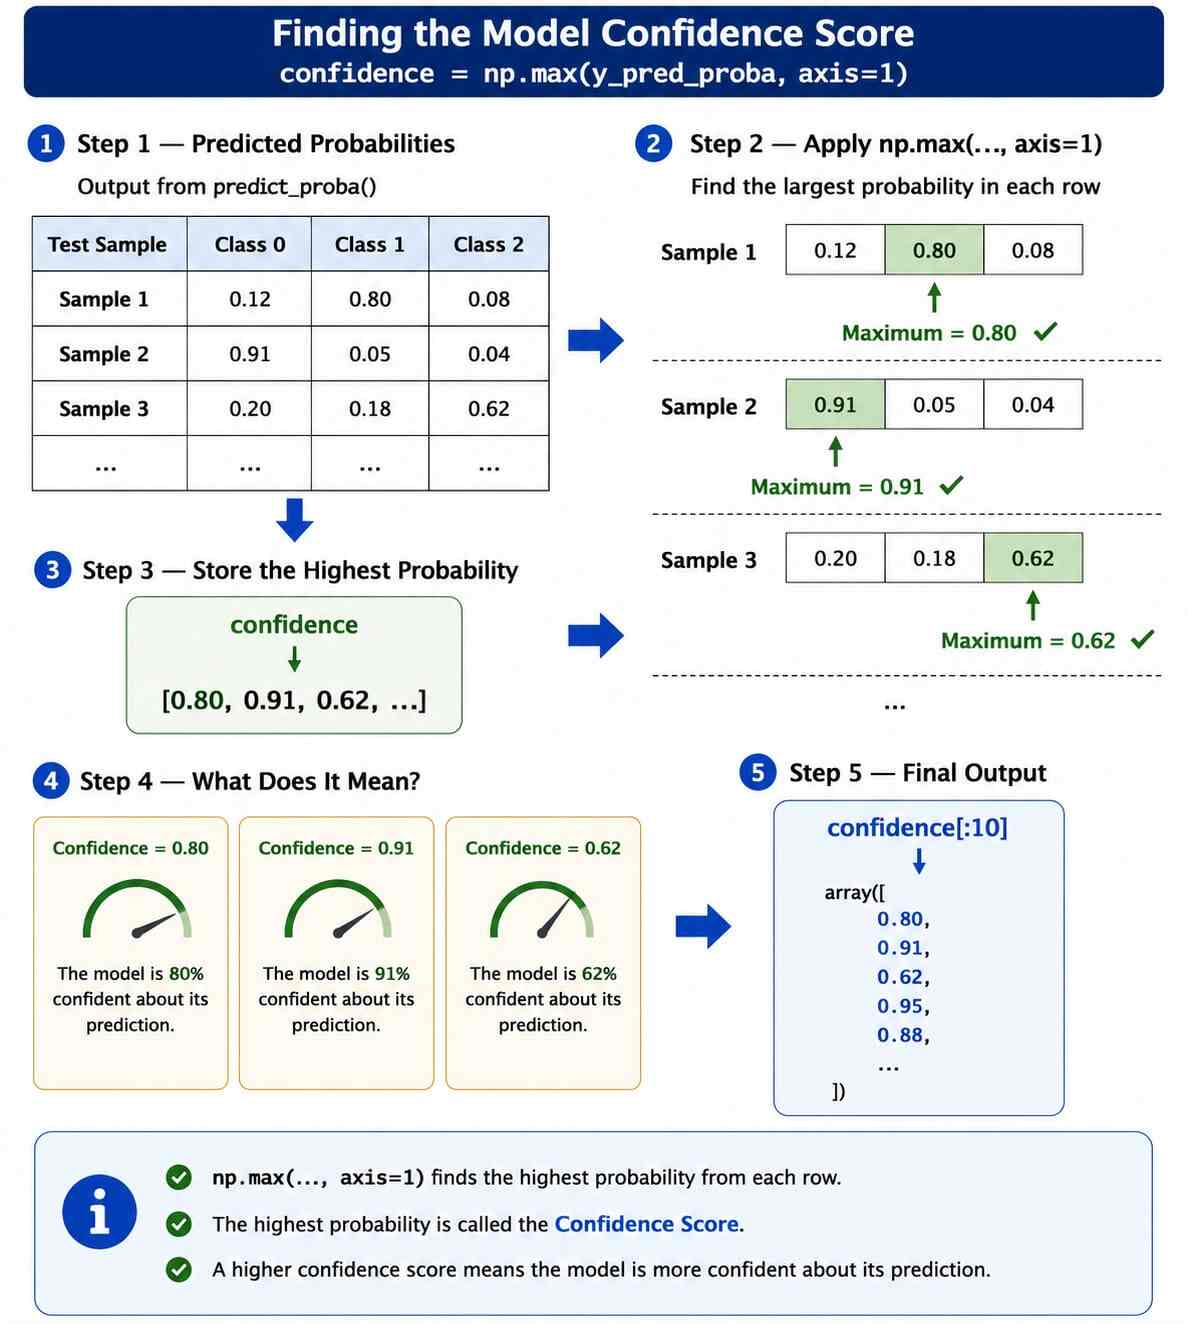

In [24]:
# Find the highest predicted probability for each test sample
confidence = np.max(y_pred_proba, axis=1)

# Display the confidence score
confidence[:10]

array([0.74516304, 0.48804064, 0.58659256, 0.77896405, 0.40088138,
       0.51809208, 0.49909076, 0.68565396, 0.57188127, 0.8212083 ])

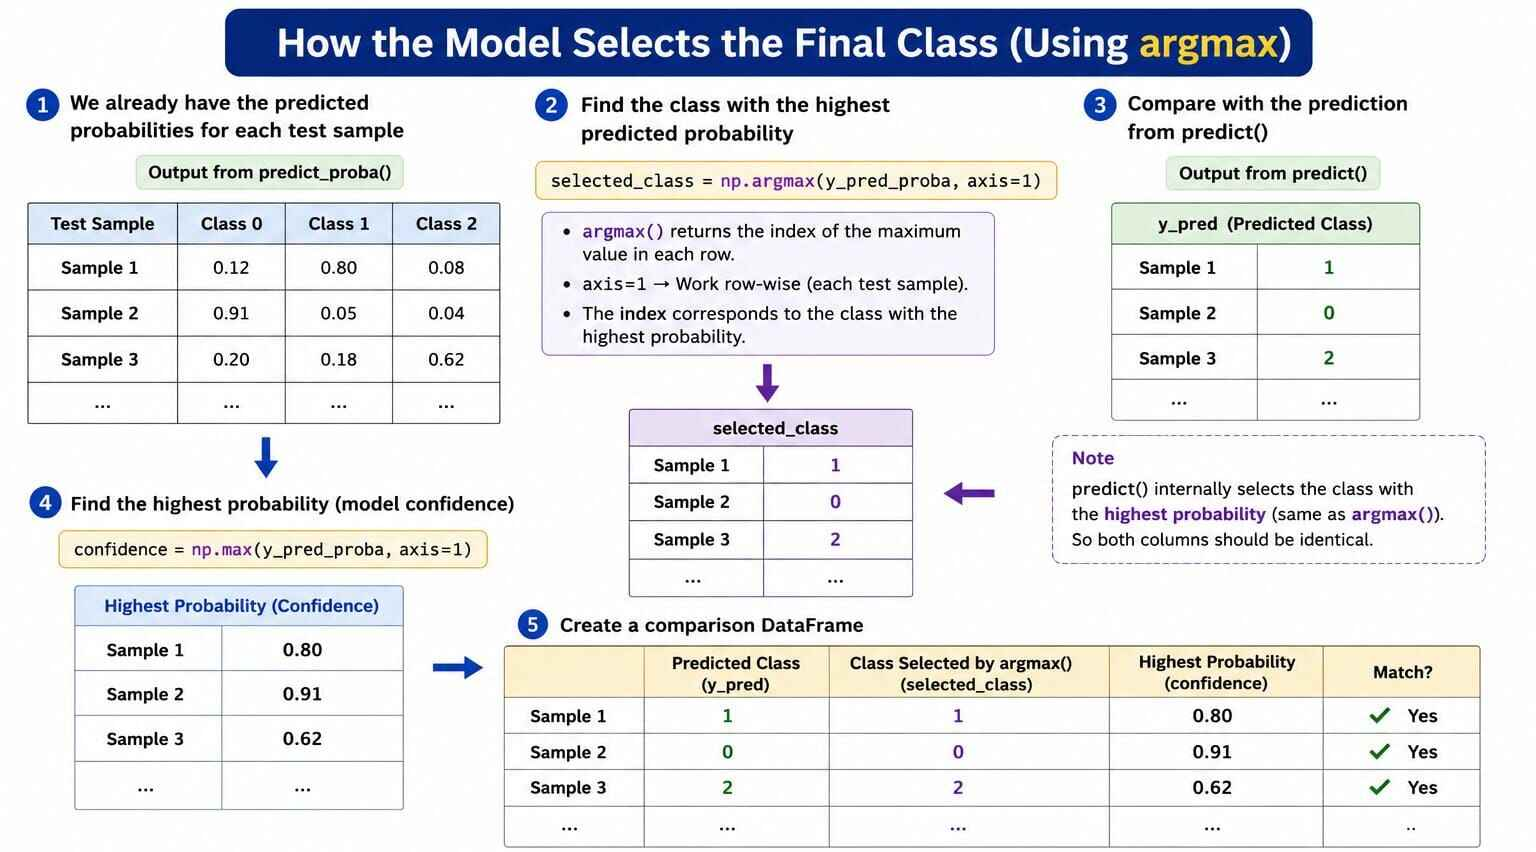

In [25]:
# Find the class with the highest predicted probability
selected_class = np.argmax(y_pred_proba, axis=1)

# Compare the predicted class with the selected class
comparison_df = pd.DataFrame({
    "Predicted Class": y_pred,
    "Class Selected by argmax()": selected_class,
    "Highest Probability": confidence
})

comparison_df.head(10)

,Predicted Class,Class Selected by argmax(),Highest Probability
0,2,2,0.745163
1,0,0,0.488041
2,1,1,0.586593
3,2,2,0.778964
4,0,0,0.400881
5,1,1,0.518092
6,2,2,0.499091
7,0,0,0.685654
8,0,0,0.571881
9,2,2,0.821208


### **Why are `Predicted Class` and `argmax()` the Same?**

The `predict()` method internally selects the class with the highest predicted probability.

The `argmax()` function also returns the index of the largest probability.

Therefore, both columns should always match.

## **Model Evaluation**

After training the Logistic Regression model, we evaluate its performance using several classification metrics.

The evaluation includes:

- **Accuracy Score** – Measures the overall percentage of correct predictions.
- **Confusion Matrix** – Shows the number of correct and incorrect predictions for each class.
- **Classification Report** – Provides Precision, Recall, F1-score, and Support for every class.

These metrics help us understand how well the model performs on unseen test data.

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate the overall accuracy of the model
score = accuracy_score(y_test, y_pred)
print("Accuracy Score:", score)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Generate a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.6833333333333333

Confusion Matrix:
[[79 15  9]
 [31 38 27]
 [ 2 11 88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.73       103
           1       0.59      0.40      0.47        96
           2       0.71      0.87      0.78       101

    accuracy                           0.68       300
   macro avg       0.67      0.68      0.66       300
weighted avg       0.67      0.68      0.67       300



**Reading the Classification Report with 3+ Classes:** Below the per-class rows, you'll see `macro avg` and `weighted avg`.

- **`macro avg`** — averages the metric across classes **equally**, regardless of how many samples each class has. Good for checking if the model is fair to smaller classes.
- **`weighted avg`** — averages the metric **weighted by class size** (number of samples). Closer to overall accuracy when classes are imbalanced.


## **Confusion Matrix Visualization**

The confusion matrix is displayed as a heatmap for better visualization.

- Higher values along the diagonal indicate correct predictions.
- Off-diagonal values represent misclassified samples.

A well-performing classifier will have most of its values concentrated along the diagonal.

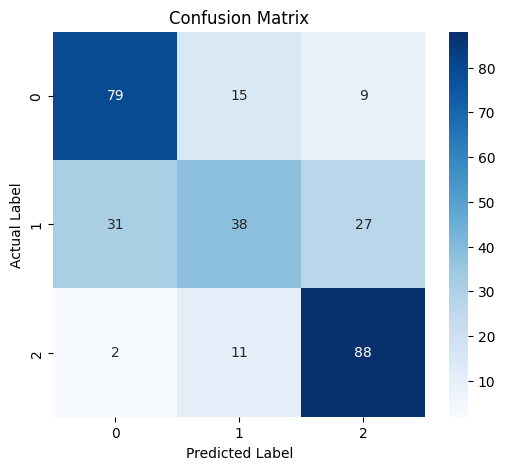

In [27]:
plt.figure(figsize=(6,5))

class_labels = sorted(df["Target"].unique())

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

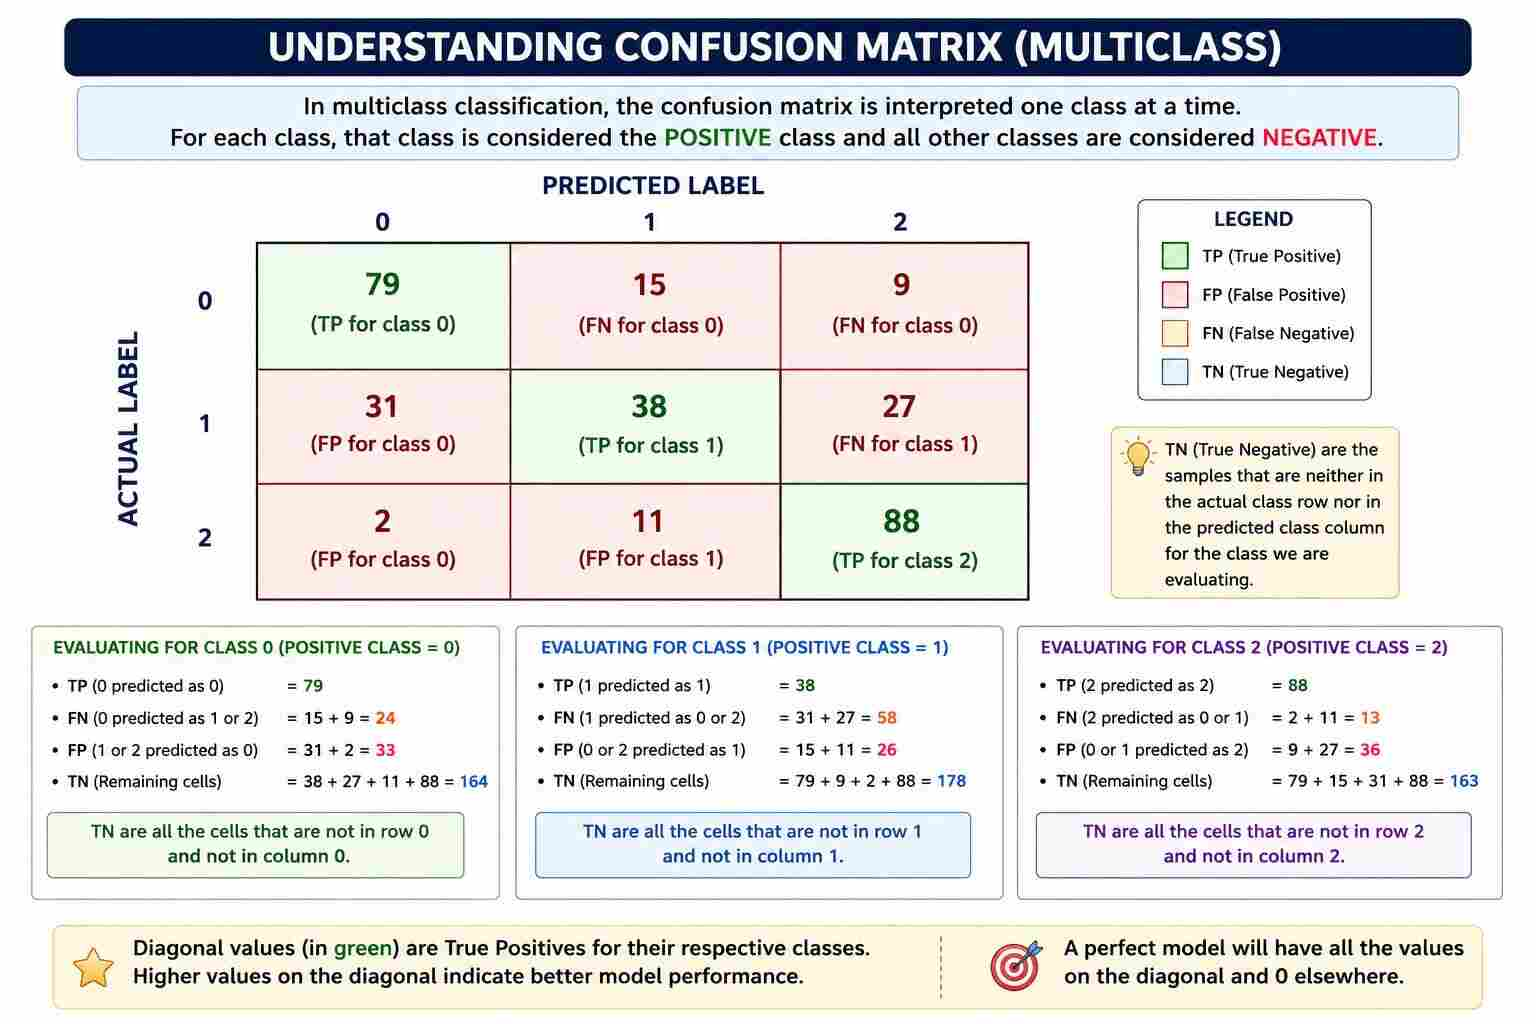



## **Conclusion — What We Learned**

- Multiclass Logistic Regression extends the binary case using either **One-vs-Rest** (multiple binary classifiers) or **Multinomial/Softmax** (one unified model).
- `predict_proba()` reveals that the model computes a probability for **every class**, not just the winning one.
- With more than 2 classes, `macro avg` and `weighted avg` in the classification report become important for judging per-class fairness vs overall performance.
- **Feature scaling** (`StandardScaler`) was applied here — a good practice this notebook got right, since Logistic Regression's optimizer converges faster and more reliably on scaled features.


